# Modeles IA v2 - Strategie d'evaluation correcte

### Features utilisees
- Symptomes : colonnes `has_*`
- Valeurs vitaminiques : `vitamin_*_percent_rda`, `serum_*`, `hemoglobin_g_dl`

### Corrections par rapport a v1
- Suppression des features non cliniques (age, bmi, lifestyle...)
- SMOTE integre dans un Pipeline (applique dans chaque fold de CV)
- Test set jamais touche jusqu'a l'evaluation finale
- Metrique principale : F1 par classe (pas accuracy)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)
import pickle

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print("SMOTE disponible")
except ImportError:
    SMOTE_AVAILABLE = False
    print("SMOTE non disponible - pip install imbalanced-learn")

print("Imports OK")

SMOTE disponible
Imports OK


## 2. Chargement des Donnees

In [2]:
DATA_PATH = "../data_csv/raw/vitamin_deficiency_disease_dataset_20260123.ods"

df = pd.read_excel(DATA_PATH, engine='odf')
print(f"Donnees chargees : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("\nDistribution des classes :")
print(df['disease_diagnosis'].value_counts())

Donnees chargees : 4000 lignes x 34 colonnes

Distribution des classes :
disease_diagnosis
Healthy                 1509
Anemia                  1245
Rickets_Osteomalacia    1029
Night_Blindness          122
Scurvy                    95
Name: count, dtype: int64


## 3. Selection des Features

On garde uniquement ce qui est cliniquement mesurable independamment du diagnostic :
- **Symptomes** : colonnes `has_*`
- **Valeurs vitaminiques** : taux sanguins et pourcentages RDA

On supprime les variables socio-economiques et de style de vie car elles ne font pas partie de l'approche choisie.

In [3]:
# Colonnes a supprimer : lifestyle / socio-economique / derives textuels
cols_to_drop = [
    'age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption',
    'exercise_level', 'diet_type', 'sun_exposure',
    'latitude_region', 'income_level',
    'symptoms_list', 'symptoms_count'
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_clean = df.drop(columns=cols_to_drop)

print("Colonnes supprimees :")
for c in cols_to_drop:
    print(f"  - {c}")

print(f"\nFeatures conservees ({df_clean.shape[1] - 1}) :")
feature_preview = [c for c in df_clean.columns if c != 'disease_diagnosis']
for c in feature_preview:
    print(f"  + {c}")

Colonnes supprimees :
  - age
  - gender
  - bmi
  - smoking_status
  - alcohol_consumption
  - exercise_level
  - diet_type
  - sun_exposure
  - latitude_region
  - income_level
  - symptoms_list
  - symptoms_count

Features conservees (21) :
  + vitamin_a_percent_rda
  + vitamin_c_percent_rda
  + vitamin_d_percent_rda
  + vitamin_e_percent_rda
  + vitamin_b12_percent_rda
  + folate_percent_rda
  + calcium_percent_rda
  + iron_percent_rda
  + hemoglobin_g_dl
  + serum_vitamin_d_ng_ml
  + serum_vitamin_b12_pg_ml
  + serum_folate_ng_ml
  + has_night_blindness
  + has_fatigue
  + has_bleeding_gums
  + has_bone_pain
  + has_muscle_weakness
  + has_numbness_tingling
  + has_memory_problems
  + has_pale_skin
  + has_multiple_deficiencies


## 4. Preprocessing

In [4]:
df_proc = df_clean.copy()

# Encoder variables categorielles (si present)
cat_cols = [c for c in df_proc.select_dtypes(include=['object']).columns
            if c != 'disease_diagnosis']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    le_dict[col] = le

# Encoder la cible
le_target = LabelEncoder()
df_proc['target'] = le_target.fit_transform(df_proc['disease_diagnosis'])

print("Classes :")
for i, c in enumerate(le_target.classes_):
    print(f"  {i} -> {c}")

feature_cols = [c for c in df_proc.columns if c not in ['disease_diagnosis', 'target']]
X = df_proc[feature_cols].values
y = df_proc['target'].values
print(f"\nX : {X.shape} | y : {y.shape}")

Classes :
  0 -> Anemia
  1 -> Healthy
  2 -> Night_Blindness
  3 -> Rickets_Osteomalacia
  4 -> Scurvy

X : (4000, 21) | y : (4000,)


## 5. Split Train / Test

**Regle importante** : le test set est mis de cote et ne sera utilise qu'une seule fois,
a la toute fin, pour l'evaluation finale. Il ne sert pas a choisir le modele.

In [5]:
# Split stratifie 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation : fit sur train uniquement, transform sur les deux
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # jamais fit sur test

print(f"Train : {X_train.shape[0]} echantillons")
print(f"Test  : {X_test.shape[0]} echantillons  <-- mis de cote jusqu'a la fin")
print("\nDistribution du test set (desequilibre reel) :")
for i, c in enumerate(le_target.classes_):
    n = (y_test == i).sum()
    print(f"  {c:<25} {n:>4} echantillons")

Train : 3200 echantillons
Test  : 800 echantillons  <-- mis de cote jusqu'a la fin

Distribution du test set (desequilibre reel) :
  Anemia                     249 echantillons
  Healthy                    302 echantillons
  Night_Blindness             24 echantillons
  Rickets_Osteomalacia       206 echantillons
  Scurvy                      19 echantillons


## 6. Cross-Validation avec SMOTE dans le Pipeline

```
Train set (80%)
  |
  └── StratifiedKFold (5 folds)
        |
        Fold 1: [train_fold x4] --> SMOTE --> entrainement
                [val_fold   x1] --> evaluation (sans SMOTE!)
        ...
        Fold 5: idem
        |
        moyenne des 5 scores F1 weighted
```

Le SMOTE est applique **a l'interieur du pipeline**, donc jamais sur le fold de validation.

In [6]:
base_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15,
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    "SVM": SVC(
        kernel='rbf', C=10, gamma='scale',
        random_state=42, probability=True
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=7, weights='distance', metric='euclidean'
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Cross-Validation (SMOTE dans pipeline) :")
print("=" * 55)

for name, model in base_models.items():
    if SMOTE_AVAILABLE:
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=3)),
            ('model', model)
        ])
    else:
        from sklearn.pipeline import Pipeline
        pipeline = Pipeline([('model', model)])

    scores = cross_val_score(
        pipeline, X_train_scaled, y_train,
        cv=cv, scoring='f1_weighted', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name:<20} CV F1: {scores.mean():.4f} +/- {scores.std():.4f}")

print("\nCV termine. Choix du modele base sur CV F1 weighted.")

Cross-Validation (SMOTE dans pipeline) :
Random Forest        CV F1: 0.9591 +/- 0.0053
SVM                  CV F1: 0.8941 +/- 0.0097
KNN                  CV F1: 0.7997 +/- 0.0143

CV termine. Choix du modele base sur CV F1 weighted.


## 7. Entrainement Final

Le meilleur modele selon CV est entraine sur **tout le train set** avec SMOTE.

In [7]:
# Choisir le meilleur modele selon CV
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"Meilleur modele selon CV : {best_name}")
print(f"CV F1 : {cv_results[best_name].mean():.4f}")

# Entrainement final sur tout le train set
best_model = base_models[best_name]

if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)
else:
    X_train_final, y_train_final = X_train_scaled, y_train

# Entrainer tous les modeles pour comparaison finale
trained_models = {}
for name, model in base_models.items():
    model.fit(X_train_final, y_train_final)
    trained_models[name] = model
    print(f"{name} entraine.")

Meilleur modele selon CV : Random Forest
CV F1 : 0.9591
Random Forest entraine.
SVM entraine.
KNN entraine.


## 8. Evaluation Finale sur le Test Set

**Une seule fois.** Le test set n'a jamais ete vu pendant l'entrainement ou la CV.

In [8]:
results = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'y_pred'      : y_pred,
        'accuracy'    : accuracy_score(y_test, y_pred),
        'f1_weighted' : f1_score(y_test, y_pred, average='weighted'),
        'cv_mean'     : cv_results[name].mean(),
        'cv_std'      : cv_results[name].std()
    }

print("Resultats sur le test set :")
print("=" * 55)
for name, res in results.items():
    print(f"{name:<20} Acc: {res['accuracy']:.4f}  F1: {res['f1_weighted']:.4f}  CV: {res['cv_mean']:.4f}")

Resultats sur le test set :
Random Forest        Acc: 0.9437  F1: 0.9444  CV: 0.9591
SVM                  Acc: 0.8938  F1: 0.8937  CV: 0.8941
KNN                  Acc: 0.7800  F1: 0.7948  CV: 0.7997


## 9. Matrices de Confusion

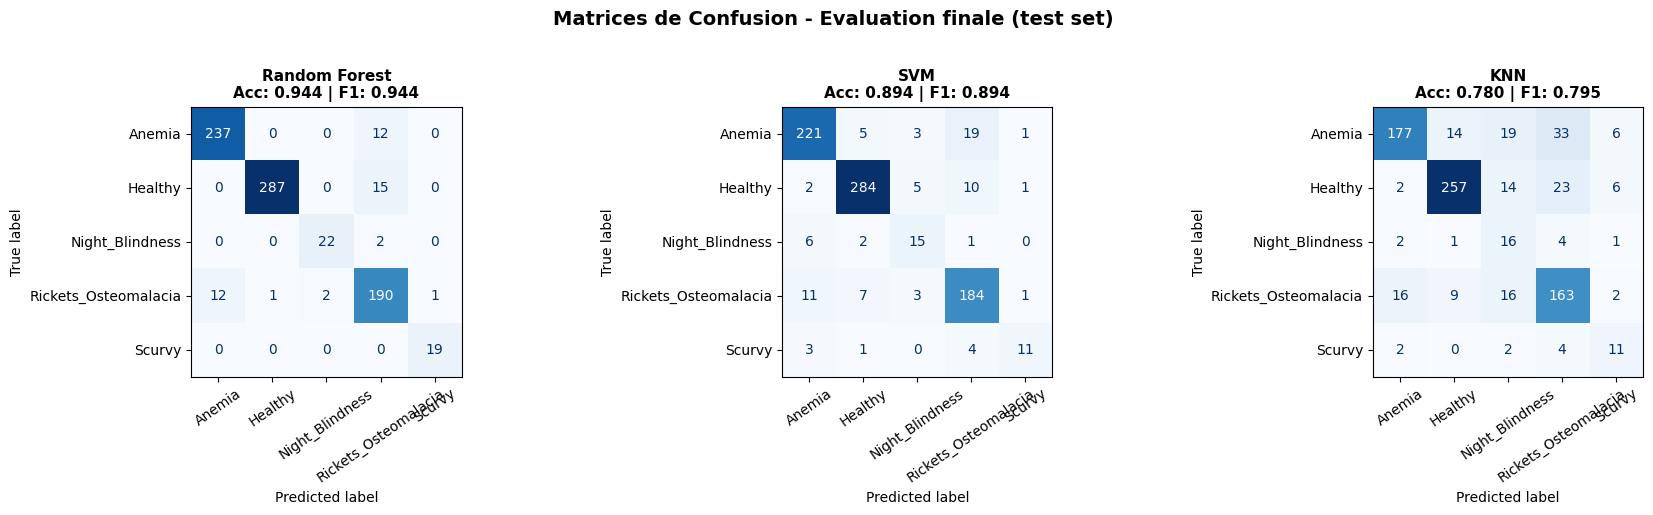

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f} | F1: {res['f1_weighted']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=35)

plt.suptitle("Matrices de Confusion - Evaluation finale (test set)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrices_confusion_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Rapport Detaille par Classe

Focus sur **Scurvy** et **Night_Blindness** : classes minoritaires, les plus difficiles.

In [10]:
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f"{name}")
    print('='*55)
    print(classification_report(
        y_test, res['y_pred'],
        target_names=le_target.classes_,
        digits=3
    ))


Random Forest
                      precision    recall  f1-score   support

              Anemia      0.952     0.952     0.952       249
             Healthy      0.997     0.950     0.973       302
     Night_Blindness      0.917     0.917     0.917        24
Rickets_Osteomalacia      0.868     0.922     0.894       206
              Scurvy      0.950     1.000     0.974        19

            accuracy                          0.944       800
           macro avg      0.937     0.948     0.942       800
        weighted avg      0.946     0.944     0.944       800


SVM
                      precision    recall  f1-score   support

              Anemia      0.909     0.888     0.898       249
             Healthy      0.950     0.940     0.945       302
     Night_Blindness      0.577     0.625     0.600        24
Rickets_Osteomalacia      0.844     0.893     0.868       206
              Scurvy      0.786     0.579     0.667        19

            accuracy                         

## 11. Comparaison des Modeles

,Modele,CV F1,CV Std,Test F1,Test Acc
0,Random Forest,0.9591,0.0053,0.9444,0.9438
1,SVM,0.8941,0.0097,0.8937,0.8938
2,KNN,0.7997,0.0143,0.7948,0.7800


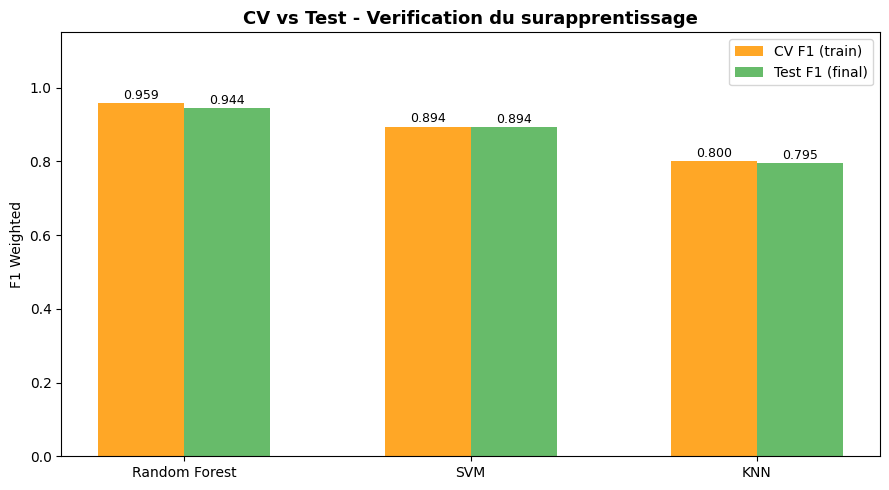

Si CV F1 ~ Test F1 => pas de surapprentissage
Si CV F1 >> Test F1 => surapprentissage detecte


In [11]:
comparison = pd.DataFrame({
    'Modele'      : list(results.keys()),
    'CV F1'       : [r['cv_mean']     for r in results.values()],
    'CV Std'      : [r['cv_std']      for r in results.values()],
    'Test F1'     : [r['f1_weighted'] for r in results.values()],
    'Test Acc'    : [r['accuracy']    for r in results.values()]
}).sort_values('Test F1', ascending=False).reset_index(drop=True)

display(comparison.round(4))

# Graphique CV vs Test
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison))
w = 0.3

b1 = ax.bar(x - w/2, comparison['CV F1'],   w, label='CV F1 (train)',   color='#FF9800', alpha=0.85)
b2 = ax.bar(x + w/2, comparison['Test F1'], w, label='Test F1 (final)', color='#4CAF50', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Modele'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 Weighted')
ax.set_title('CV vs Test - Verification du surapprentissage', fontsize=13, fontweight='bold')
ax.legend()

for bars in [b1, b2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparaison_cv_test_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("Si CV F1 ~ Test F1 => pas de surapprentissage")
print("Si CV F1 >> Test F1 => surapprentissage detecte")

## 12. Importance des Features (Random Forest)

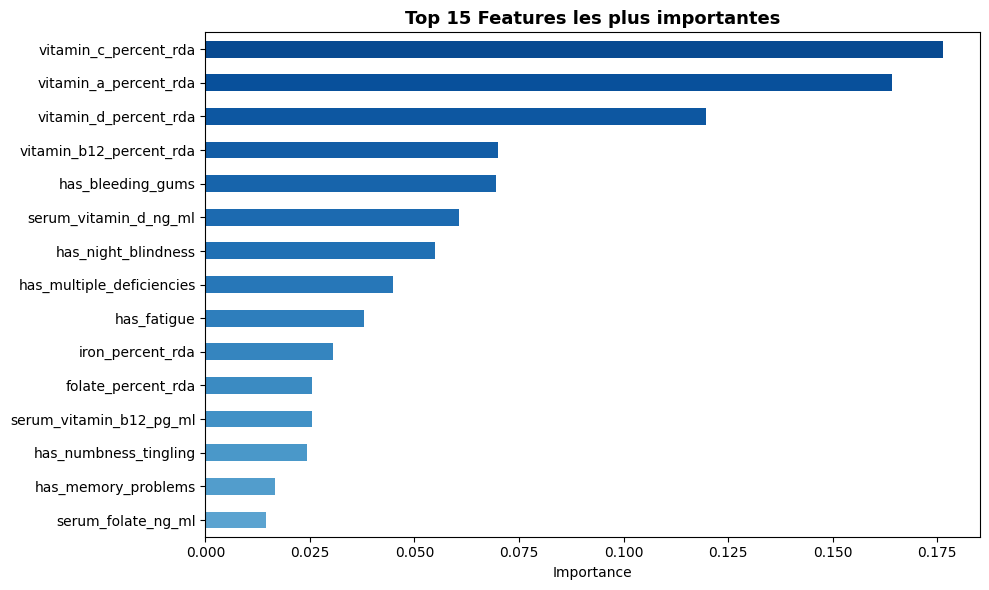

Top 10 :
   1. vitamin_c_percent_rda               0.1764
   2. vitamin_a_percent_rda               0.1642
   3. vitamin_d_percent_rda               0.1198
   4. vitamin_b12_percent_rda             0.0700
   5. has_bleeding_gums                   0.0695
   6. serum_vitamin_d_ng_ml               0.0607
   7. has_night_blindness                 0.0550
   8. has_multiple_deficiencies           0.0449
   9. has_fatigue                         0.0379
  10. iron_percent_rda                    0.0304


In [12]:
rf = trained_models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(importances)))[::-1]
importances.head(15).plot(kind='barh', color=colors_bar)
plt.title("Top 15 Features les plus importantes", fontsize=13, fontweight='bold')
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 :")
for i, (feat, imp) in enumerate(importances.head(10).items(), 1):
    print(f"  {i:2}. {feat:<35} {imp:.4f}")

## 13. Sauvegarde du Meilleur Modele

In [13]:
best_final = comparison.iloc[0]['Modele']
best_model_final = trained_models[best_final]

with open(f'best_model_v2_{best_final.replace(" ", "_")}.pkl', 'wb') as f:
    pickle.dump(best_model_final, f)
with open('scaler_v2.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder_v2.pkl', 'wb') as f:
    pickle.dump(le_target, f)
with open('feature_cols_v2.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print(f"Meilleur modele : {best_final}")
print(f"Test F1  : {results[best_final]['f1_weighted']:.4f}")
print(f"Test Acc : {results[best_final]['accuracy']:.4f}")
print("\nFichiers sauvegardes :")
print(f"  best_model_v2_{best_final.replace(' ', '_')}.pkl")
print("  scaler_v2.pkl")
print("  label_encoder_v2.pkl")
print("  feature_cols_v2.pkl")

Meilleur modele : Random Forest
Test F1  : 0.9444
Test Acc : 0.9437

Fichiers sauvegardes :
  best_model_v2_Random_Forest.pkl
  scaler_v2.pkl
  label_encoder_v2.pkl
  feature_cols_v2.pkl


ABLATION STUDY — Impact des features symptômes (has_*)
